In [9]:
SUSPICIOUS_FILE_PATH = '../data/processed/suspicious_domains_medium.txt'
ALL_FILE_PATH = '../data/processed/relayed_conn_categories_medium.txt'

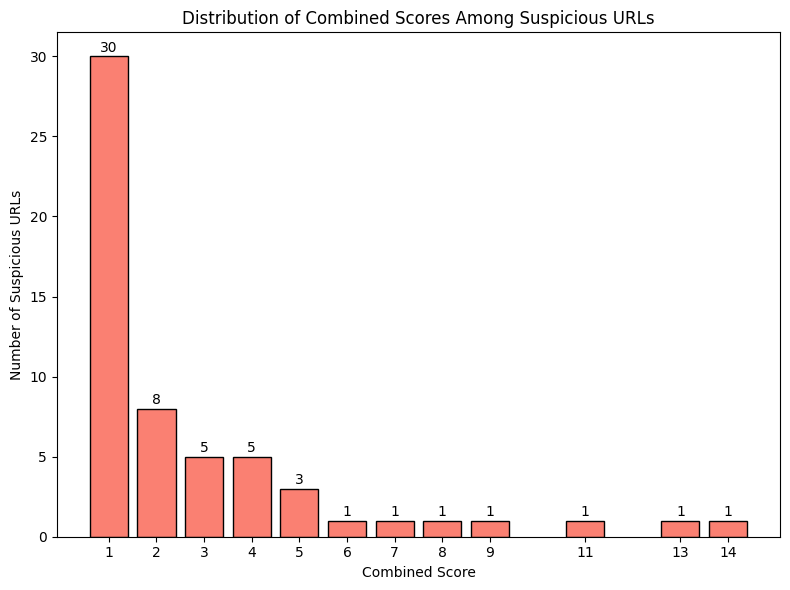

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the suspicious domains data
suspicious_df = pd.read_csv(SUSPICIOUS_FILE_PATH)

# Ensure 'Combined Score' is treated as a categorical variable if it's discrete
suspicious_df['Combined Score'] = suspicious_df['Combined Score'].astype(int)

# Count the number of domains per combined score
score_counts = suspicious_df['Combined Score'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(score_counts.index, score_counts.values, color='salmon', edgecolor='black')

# Add labels and title
plt.xlabel('Combined Score')
plt.ylabel('Number of Suspicious URLs')
plt.title('Distribution of Combined Scores Among Suspicious URLs')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             '%d' % int(height), ha='center', va='bottom')

plt.xticks(score_counts.index)  # Ensure all scores are shown on the x-axis
plt.tight_layout()
plt.savefig('combined_score_bar_chart.png', dpi=300)
plt.show()


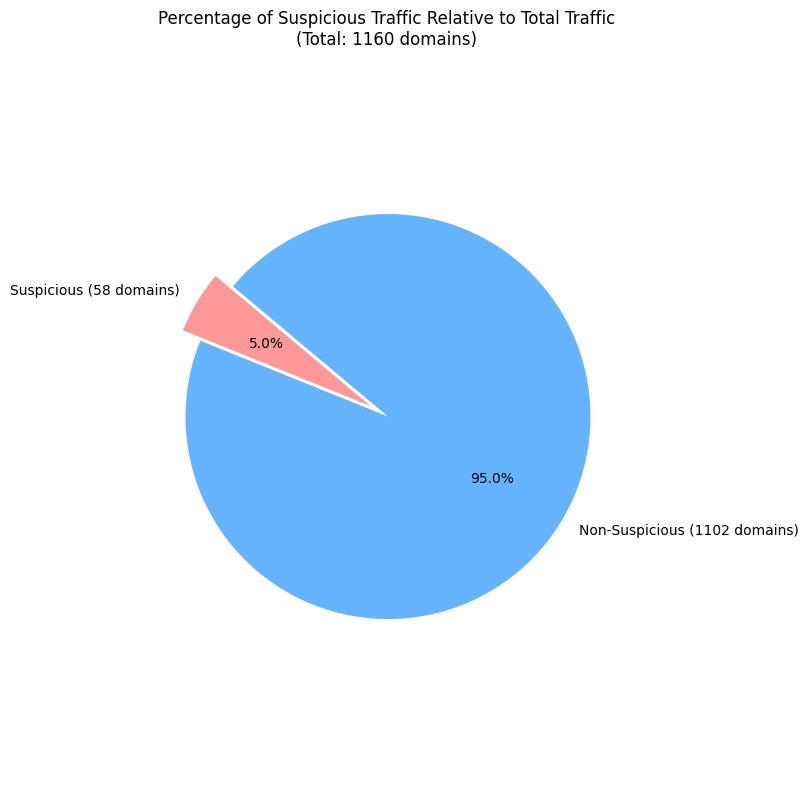

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
suspicious_df = pd.read_csv(SUSPICIOUS_FILE_PATH)
all_domains_df = pd.read_csv(ALL_FILE_PATH)

# Calculate the number of suspicious and non-suspicious domains
num_suspicious = suspicious_df['Domain'].nunique()
num_total = all_domains_df['Domain'].nunique()
num_non_suspicious = num_total - num_suspicious

# Prepare data for the pie chart
labels = [
    f"Suspicious ({num_suspicious} domains)", 
    f"Non-Suspicious ({num_non_suspicious} domains)"
]
sizes = [num_suspicious, num_non_suspicious]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the 'Suspicious' slice

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode,
    autopct='%1.1f%%', 
    startangle=140
)
plt.title(f'Percentage of Suspicious Traffic Relative to Total Traffic\n(Total: {num_total} domains)')
plt.axis('equal')  # Ensures the pie chart is circular
plt.tight_layout()
plt.savefig('percentage_of_suspicious_traffic', dpi=300)
plt.show()
